# Day 15

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/current_catalog_cleaned.csv")

df.head()

,norad_id,name,object_type,satellite_constellation,altitude_km,altitude_category,orbital_band,congestion_risk,inclination,eccentricity,launch_year_estimate,days_in_orbit_estimate,orbit_lifetime_category,mean_motion,epoch,data_source,snapshot_date,country,last_seen
0,900,CALSPHERE 1,PAYLOAD,Other,975.794787,Low LEO,LEO-Polar,LOW,90.2213,0.002375,2024,0,<1yr,13.766495,2026-07-13 03:15:37.038240,celestrak,2026-07-13,US,2026-07-13
1,902,CALSPHERE 2,PAYLOAD,Other,1061.599445,Mid LEO,LEO-Polar,LOW,90.2347,0.001955,2024,0,<1yr,13.529023,2026-07-13 03:50:06.194688,celestrak,2026-07-13,US,2026-07-13
2,1361,LCS 1,PAYLOAD,Other,2787.866858,High LEO,MEO,LOW,32.1398,0.001237,2024,0,<1yr,9.893107,2026-07-13 05:22:30.480096,celestrak,2026-07-13,US,2026-07-13
3,1512,TEMPSAT 1,PAYLOAD,Other,1133.231902,Mid LEO,LEO-Polar,HIGH,89.9978,0.006993,2024,0,<1yr,13.335955,2026-07-13 11:40:59.394720,celestrak,2026-07-13,US,2026-07-13
4,1520,CALSPHERE 4A,PAYLOAD,Other,1123.157652,Mid LEO,LEO-Polar,HIGH,89.8990,0.007140,2024,0,<1yr,13.362829,2026-07-13 12:07:15.869856,celestrak,2026-07-13,US,2026-07-13


- Correlation for numeric columns

In [3]:
numeric_df = df.select_dtypes(include="number")

numeric_df.corr()

,norad_id,altitude_km,inclination,eccentricity,launch_year_estimate,days_in_orbit_estimate,mean_motion
norad_id,1.000000,-0.379610,0.127161,-0.070471,0.043748,-0.023984,0.419597
altitude_km,-0.379610,1.000000,-0.422381,0.263532,0.016750,0.122909,-0.934953
inclination,0.127161,-0.422381,1.000000,-0.009428,-0.016428,-0.000707,0.379299
eccentricity,-0.070471,0.263532,-0.009428,1.000000,-0.010013,0.187960,-0.233363
launch_year_estimate,0.043748,0.016750,-0.016428,-0.010013,1.000000,-0.050305,-0.042346
days_in_orbit_estimate,-0.023984,0.122909,-0.000707,0.187960,-0.050305,1.000000,-0.097917
mean_motion,0.419597,-0.934953,0.379299,-0.233363,-0.042346,-0.097917,1.000000


- Plot the correlation matrix

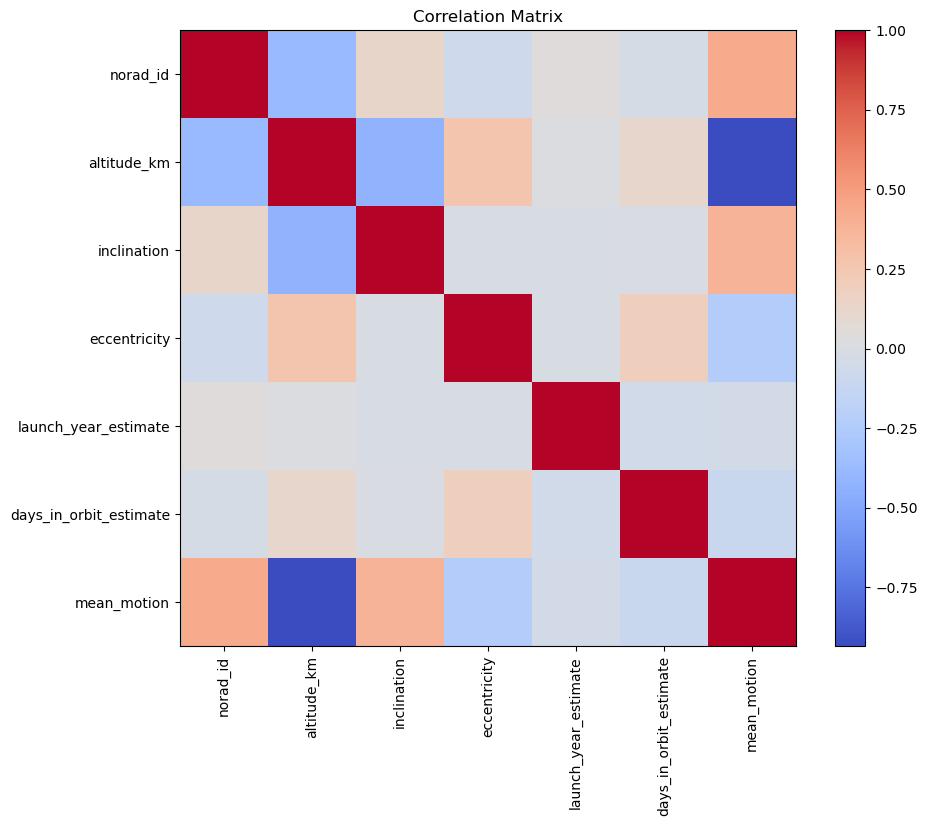

In [4]:
plt.figure(figsize=(10,8))

plt.imshow(numeric_df.corr(), cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)

plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)

plt.title("Correlation Matrix")

plt.show()

### Variance analysis

 - Mean Motion variance by Object Type

In [5]:
variance_object = df.groupby("object_type")["mean_motion"].var()

print(variance_object)

object_type
DEBRIS               NaN
PAYLOAD         9.775033
ROCKET BODY    15.425969
UNKNOWN         1.214142
Name: mean_motion, dtype: float64


- Plot it.

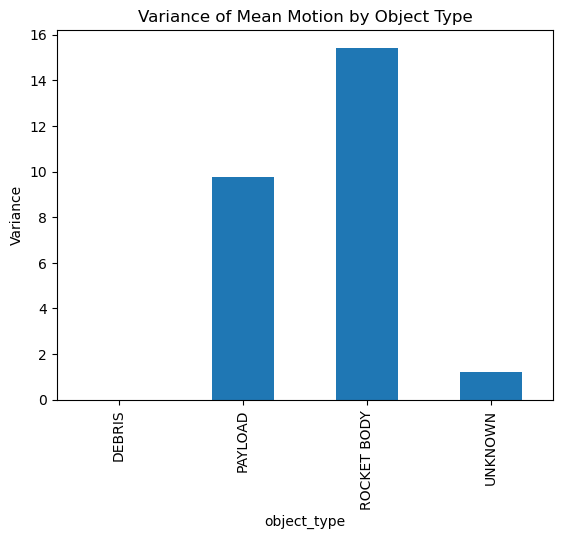

In [6]:
variance_object.plot(kind="bar")

plt.title("Variance of Mean Motion by Object Type")

plt.ylabel("Variance")

plt.show()

- Mean Motion variance by Altitude Category

In [7]:
variance_altitude = df.groupby("altitude_category")["mean_motion"].var()

print(variance_altitude)

altitude_category
Beyond GEO      0.074844
GEO             0.000005
High LEO        1.928020
Low LEO         0.102379
MEO             0.069397
Mid LEO         0.067845
Very Low LEO    0.069611
Name: mean_motion, dtype: float64


- plot

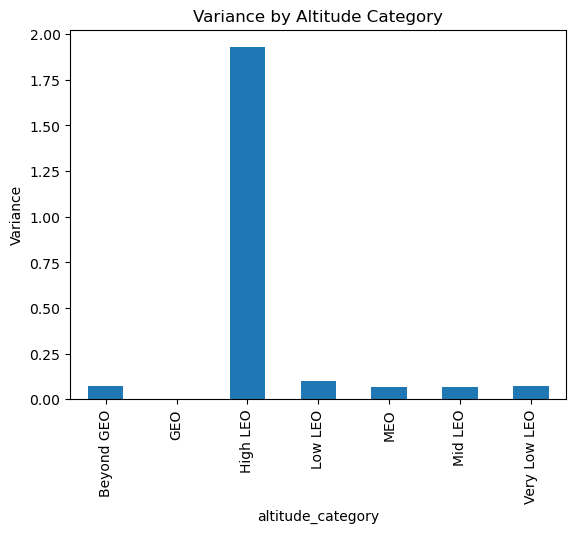

In [8]:
variance_altitude.plot(kind="bar")

plt.title("Variance by Altitude Category")

plt.ylabel("Variance")

plt.show()

- Variance by Eccentricity

In [9]:
print(df["eccentricity"].var())

0.001539826608171122


### Hypothesis

### Statistical Validation

### Null Hypothesis (H0)

There is no significant difference in mean motion across different object types.

### Alternative Hypothesis (H1)

Mean motion differs across different object types.

In [10]:
df.groupby("object_type")["mean_motion"].mean()

object_type
DEBRIS         15.952557
PAYLOAD        14.401472
ROCKET BODY    13.301954
UNKNOWN        15.225780
Name: mean_motion, dtype: float64

### Interpretation

The average mean motion is different for each object type.

Payloads have a different average mean motion compared to debris and rocket bodies.

This suggests that object type has an effect on mean motion in this dataset.

### Limitations

- This dataset is only a snapshot of current satellite records.
- Results may change when new satellite data is added.
- The analysis is descriptive and does not prove causation.
- Country is a categorical feature, so it cannot be directly correlated with numeric variables.